Files saved: train.csv and test.csv
                                             Reviews Sentiment
0  When I first tuned in on this morning news, I ...       neg
1  Mere thoughts of "Going Overboard" (aka "Babes...       neg
2  Why does this movie fall WELL below standards?...       neg
3  Wow and I thought that any Steven Segal movie ...       neg
4  The story is seen before, but that does'n matt...       neg
                                             Reviews Sentiment
0  Who would have thought that a movie about a ma...       pos
1  After realizing what is going on around us ......       pos
2  I grew up watching the original Disney Cindere...       neg
3  David Mamet wrote the screenplay and made his ...       pos
4  Admittedly, I didn't have high expectations of...       neg
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Reviews    25000 

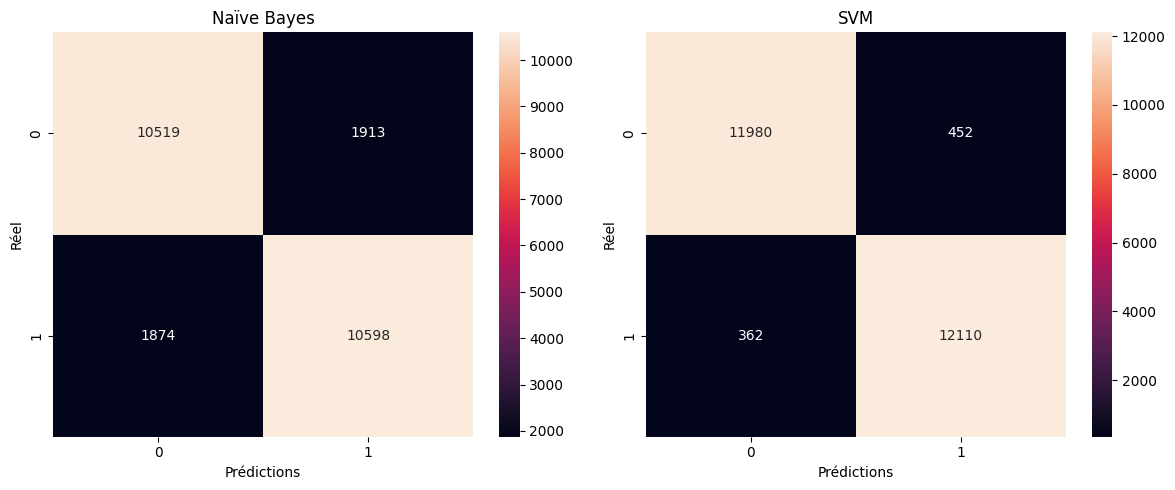

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import HashingVectorizer


train_url = 'https://github.com/laxmimerit/IMDB-Movie-Reviews-Large-Dataset-50k/raw/80041b5d0966bc82386119edb7710d127ec99de2/train.xlsx'
test_url  = 'https://github.com/laxmimerit/IMDB-Movie-Reviews-Large-Dataset-50k/raw/80041b5d0966bc82386119edb7710d127ec99de2/test.xlsx'

train_data = pd.read_excel(train_url)
test_data  = pd.read_excel(test_url)

# Convert to CSV
train_data.to_csv("train.csv", index=False)
test_data.to_csv("test.csv", index=False)

print("Files saved: train.csv and test.csv")

train_data = pd.read_csv("train.csv")
test_data  = pd.read_csv("test.csv")

print(train_data.head())
print(test_data.head())

# Visualiser les informations sur les données
print(train_data.info())
print(test_data.info())


# Vérifier les valeurs manquantes
print(train_data.isnull().sum())
print(test_data.isnull().sum())

# Supprimer les doublons et les valeurs manquantes et convertir tout les reviews en str
train_data.drop_duplicates(inplace=True)
train_data.dropna(inplace=True)
test_data.drop_duplicates(inplace=True)
test_data.dropna(inplace=True)

train_data['Reviews'] = train_data['Reviews'].astype(str)
test_data['Reviews'] = test_data['Reviews'].astype(str)

# Convertir les labels en numérique : 'positive' = 1, 'negative' = 0
train_data['Sentiment'] = train_data['Sentiment'].map({'pos': 1, 'neg': 0})
test_data['Sentiment'] = test_data['Sentiment'].map({'pos': 1, 'neg': 0})

vectorizer = HashingVectorizer(n_features=5000, stop_words='english', alternate_sign=False)
X_train = vectorizer.transform(train_data['Reviews'])  # HashingVectorizer does not need fit
y_train = train_data['Sentiment']

X_test = vectorizer.transform(test_data['Reviews'])
y_test = test_data['Sentiment']

# modèlisation
# Naiiv Bayes
model_nb = MultinomialNB()
model_nb.fit(X_train, y_train)
y_pred_nb = model_nb.predict(X_test)

# SVM
model_svc = SVC()
model_svc.fit(X_train, y_train)
y_pred_svc = model_svc.predict(X_test)

#evaluation
print("Naïve Bayes :")
print(classification_report(y_test, y_pred_nb))
print("Accuracy :", accuracy_score(y_test, y_pred_nb))

print("\nSVM :")
print(classification_report(y_test, y_pred_svc))
print("Accuracy :", accuracy_score(y_test, y_pred_svc))

#visualisation :
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', ax=axes[0])
axes[0].set_title('Naïve Bayes')
axes[0].set_xlabel('Prédictions')
axes[0].set_ylabel('Réel')

sns.heatmap(confusion_matrix(y_test, y_pred_svc), annot=True, fmt='d', ax=axes[1])
axes[1].set_title('SVM')
axes[1].set_xlabel('Prédictions')
axes[1].set_ylabel('Réel')

plt.tight_layout()
plt.show()

